In [2]:
!pip -V

pip 24.2 from C:\Users\s_ani\Documents\textbooks\5thSem\Deeplearning\venv\Lib\site-packages\pip (python 3.11)



In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from io import StringIO
%matplotlib inline

In [7]:
with open('fifa_19.csv', 'rb') as file:
    content = file.read()
content = content.decode('utf-8', errors='ignore')
file = StringIO(content)
df = pd.read_csv(file, engine='python')

In [8]:
df = df[['Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 'FKAccuracy',
'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance',
'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression','Interceptions',
'Positioning', 'Vision', 'Penalties', 'Composure', 'Marking', 'StandingTackle', 'SlidingTackle',
'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes', 'Position']]

In [9]:
Goalkeeper = ["GK"]
Forward_Player = ["ST", "LW", "RW", "LF", "RF", "RS","LS", "CF"]
Midfielder_Player = ["CM", "RCM", "LCM", "CDM", "RDM", "LDM", "CAM", "LAM",
"RAM", "RM", "LM"]
Defender_Player = ["CB", "RCB", "LCB", "LWB", "RWB", "LB", "RB"]

In [10]:
df.loc[df['Position'].isin(Goalkeeper), 'Position'] = 'GK'
df.loc[df['Position'].isin(Forward_Player), 'Position'] = 'F'
df.loc[df['Position'].isin(Midfielder_Player), 'Position'] = 'M'
df.loc[df['Position'].isin(Defender_Player), 'Position'] = 'D'

In [11]:
df = df.dropna(axis=0)
encoder = LabelEncoder()
df['Position'] = encoder.fit_transform(df['Position'])

In [12]:
X = pd.DataFrame(df.drop(['Position'], axis=1))
y = pd.DataFrame(df['Position'])

In [13]:
scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

In [15]:
X

,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
0,1.000000,0.733333,0.965116,0.953488,1.000000,0.988636,1.000000,0.928571,1.000000,0.929412,...,0.804598,1.000000,0.329670,0.285714,0.261364,0.056180,0.109890,0.155556,0.146067,0.075269
1,0.989247,0.944444,0.860465,0.965116,0.903226,0.852273,0.802198,0.809524,0.978022,0.905882,...,0.919540,0.989247,0.274725,0.318681,0.227273,0.067416,0.109890,0.155556,0.146067,0.107527
2,0.913978,0.644444,0.895349,0.930233,0.989247,0.931818,0.923077,0.821429,0.989011,0.964706,...,0.873563,0.978495,0.263736,0.241758,0.340909,0.089888,0.087912,0.155556,0.157303,0.107527
3,0.118280,0.188889,0.500000,0.104651,0.150538,0.170455,0.175824,0.500000,0.406593,0.529412,...,0.402299,0.698925,0.131868,0.208791,0.113636,1.000000,0.923077,0.955556,0.977528,1.000000
4,0.860215,0.566667,0.988372,0.906977,0.881720,0.897727,0.879121,0.976190,0.945055,0.776471,...,0.850575,0.913978,0.714286,0.615385,0.545455,0.157303,0.131868,0.044444,0.101124,0.129032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18142,0.387097,0.400000,0.488372,0.244186,0.408602,0.272727,0.340659,0.428571,0.417582,0.494118,...,0.436782,0.451613,0.406593,0.505495,0.500000,0.101124,0.131868,0.066667,0.078652,0.086022
18143,0.537634,0.533333,0.418605,0.372093,0.376344,0.295455,0.186813,0.190476,0.384615,0.341176,...,0.436782,0.419355,0.208791,0.142857,0.181818,0.101124,0.087912,0.088889,0.044944,0.118280
18144,0.408602,0.466667,0.360465,0.395349,0.440860,0.363636,0.263736,0.226190,0.428571,0.682353,...,0.574713,0.408602,0.318681,0.120879,0.090909,0.056180,0.043956,0.100000,0.056180,0.129032
18145,0.516129,0.388889,0.406977,0.418605,0.505376,0.318182,0.318681,0.273810,0.516484,0.576471,...,0.517241,0.462366,0.186813,0.252747,0.272727,0.146067,0.054945,0.144444,0.078652,0.086022


In [16]:
num_features = 33
num_samples = 18147
lr_list = [0.1, 0.01, 0.001]
epoch_list = [10, 20, 30]
batch_size = 100

In [17]:
model1 = Sequential([
    Input(shape=(num_features,)),
    Dense(128, activation='relu'),
    Dense(4, activation='softmax')
])
model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               4352      
                                                                 
 dense_1 (Dense)             (None, 4)                 516       
                                                                 
Total params: 4868 (19.02 KB)
Trainable params: 4868 (19.02 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Epoch 1/10
147/147 [==============================] - 1s 4ms/step - loss: 0.7221 - Accuracy: 0.7361 - val_loss: 0.3559 - val_Accuracy: 0.8421
Epoch 2/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3649 - Accuracy: 0.8453 - val_loss: 0.3098 - val_Accuracy: 0.8684
Epoch 3/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3611 - Accuracy: 0.8466 - val_loss: 0.3910 - val_Accuracy: 0.8372
Epoch 4/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3702 - Accuracy: 0.8425 - val_loss: 0.3032 - val_Accuracy: 0.8739
Epoch 5/10
147/147 [==============================] - 0s 3ms/step - loss: 0.3583 - Accuracy: 0.8507 - val_loss: 0.3140 - val_Accuracy: 0.8654
Epoch 6/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3355 - Accuracy: 0.8598 - val_loss: 0.2993 - val_Accuracy: 0.8739
Epoch 7/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3411 - Accuracy: 0.8575 - val_loss: 0.3335 - val_Accuracy: 0.8513
Epoch 

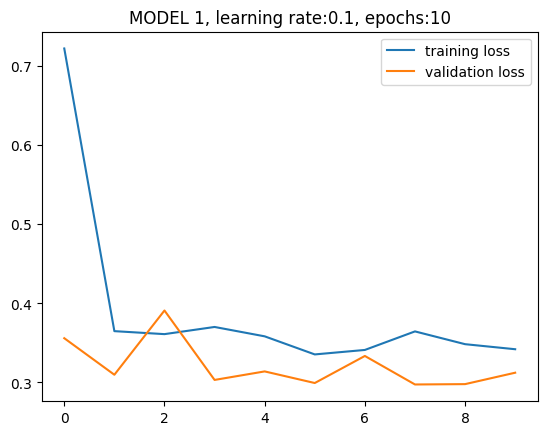

Epoch 1/20
147/147 [==============================] - 1s 3ms/step - loss: 0.3632 - Accuracy: 0.8541 - val_loss: 0.2835 - val_Accuracy: 0.8819
Epoch 2/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3418 - Accuracy: 0.8571 - val_loss: 0.3389 - val_Accuracy: 0.8531
Epoch 3/20
147/147 [==============================] - 0s 3ms/step - loss: 0.3370 - Accuracy: 0.8595 - val_loss: 0.2869 - val_Accuracy: 0.8874
Epoch 4/20
147/147 [==============================] - 0s 3ms/step - loss: 0.3435 - Accuracy: 0.8560 - val_loss: 0.3266 - val_Accuracy: 0.8629
Epoch 5/20
147/147 [==============================] - 0s 3ms/step - loss: 0.3443 - Accuracy: 0.8534 - val_loss: 0.2830 - val_Accuracy: 0.8819
Epoch 6/20
147/147 [==============================] - 0s 3ms/step - loss: 0.3382 - Accuracy: 0.8574 - val_loss: 0.3033 - val_Accuracy: 0.8819
Epoch 7/20
147/147 [==============================] - 0s 3ms/step - loss: 0.3515 - Accuracy: 0.8558 - val_loss: 0.2852 - val_Accuracy: 0.8868
Epoch 

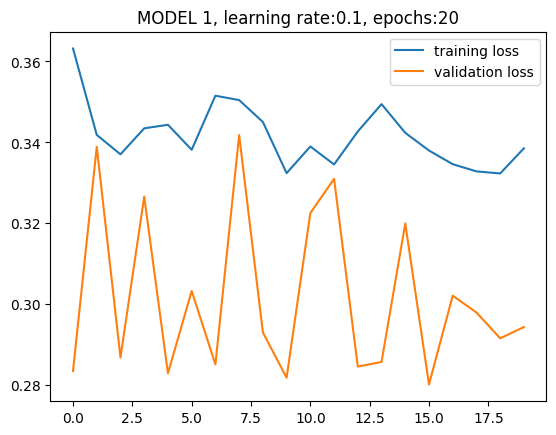

Epoch 1/30
147/147 [==============================] - 1s 3ms/step - loss: 0.3536 - Accuracy: 0.8534 - val_loss: 0.2810 - val_Accuracy: 0.8856
Epoch 2/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3294 - Accuracy: 0.8647 - val_loss: 0.2876 - val_Accuracy: 0.8849
Epoch 3/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3490 - Accuracy: 0.8552 - val_loss: 0.2851 - val_Accuracy: 0.8807
Epoch 4/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3330 - Accuracy: 0.8606 - val_loss: 0.2769 - val_Accuracy: 0.8886
Epoch 5/30
147/147 [==============================] - 0s 3ms/step - loss: 0.3279 - Accuracy: 0.8612 - val_loss: 0.2827 - val_Accuracy: 0.8776
Epoch 6/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3331 - Accuracy: 0.8598 - val_loss: 0.2853 - val_Accuracy: 0.8764
Epoch 7/30
147/147 [==============================] - 0s 3ms/step - loss: 0.3352 - Accuracy: 0.8578 - val_loss: 0.2846 - val_Accuracy: 0.8788
Epoch 

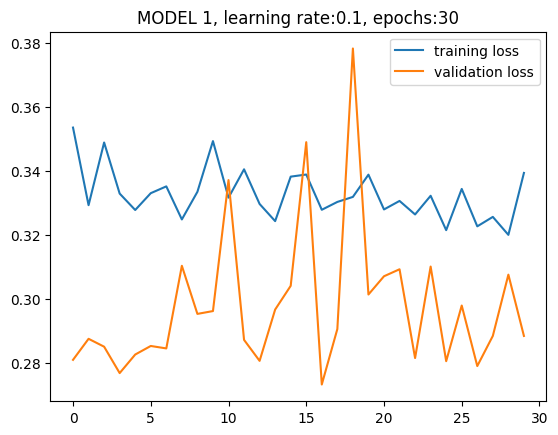

Epoch 1/10
147/147 [==============================] - 1s 4ms/step - loss: 0.3053 - Accuracy: 0.8737 - val_loss: 0.2769 - val_Accuracy: 0.8880
Epoch 2/10
147/147 [==============================] - 0s 3ms/step - loss: 0.3036 - Accuracy: 0.8725 - val_loss: 0.2743 - val_Accuracy: 0.8886
Epoch 3/10
147/147 [==============================] - 0s 3ms/step - loss: 0.3027 - Accuracy: 0.8728 - val_loss: 0.2704 - val_Accuracy: 0.8837
Epoch 4/10
147/147 [==============================] - 0s 3ms/step - loss: 0.3029 - Accuracy: 0.8745 - val_loss: 0.2714 - val_Accuracy: 0.8874
Epoch 5/10
147/147 [==============================] - 0s 3ms/step - loss: 0.3028 - Accuracy: 0.8728 - val_loss: 0.2877 - val_Accuracy: 0.8764
Epoch 6/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3030 - Accuracy: 0.8719 - val_loss: 0.2738 - val_Accuracy: 0.8837
Epoch 7/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3026 - Accuracy: 0.8727 - val_loss: 0.2757 - val_Accuracy: 0.8837
Epoch 

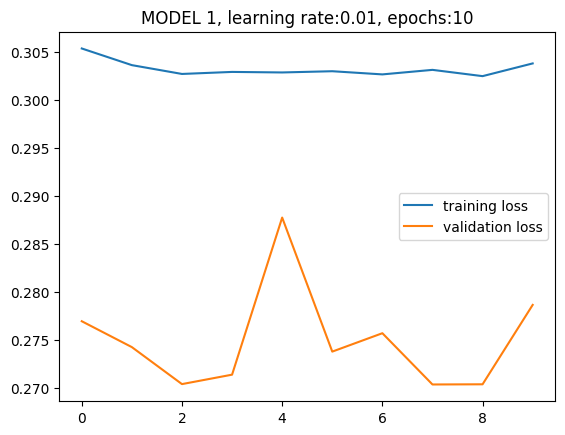

Epoch 1/20
147/147 [==============================] - 1s 3ms/step - loss: 0.3028 - Accuracy: 0.8714 - val_loss: 0.2707 - val_Accuracy: 0.8849
Epoch 2/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3028 - Accuracy: 0.8721 - val_loss: 0.2699 - val_Accuracy: 0.8880
Epoch 3/20
147/147 [==============================] - 0s 3ms/step - loss: 0.3005 - Accuracy: 0.8729 - val_loss: 0.2710 - val_Accuracy: 0.8837
Epoch 4/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3021 - Accuracy: 0.8729 - val_loss: 0.2745 - val_Accuracy: 0.8831
Epoch 5/20
147/147 [==============================] - 0s 3ms/step - loss: 0.3014 - Accuracy: 0.8739 - val_loss: 0.2704 - val_Accuracy: 0.8837
Epoch 6/20
147/147 [==============================] - 0s 3ms/step - loss: 0.3024 - Accuracy: 0.8734 - val_loss: 0.2794 - val_Accuracy: 0.8825
Epoch 7/20
147/147 [==============================] - 0s 3ms/step - loss: 0.3021 - Accuracy: 0.8730 - val_loss: 0.2741 - val_Accuracy: 0.8788
Epoch 

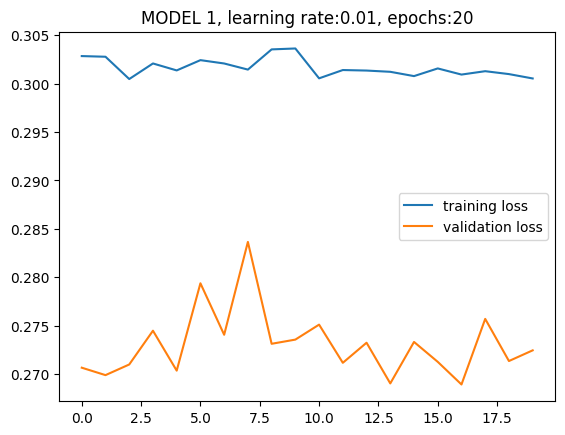

Epoch 1/30
147/147 [==============================] - 1s 4ms/step - loss: 0.3007 - Accuracy: 0.8736 - val_loss: 0.2679 - val_Accuracy: 0.8868
Epoch 2/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3006 - Accuracy: 0.8741 - val_loss: 0.2683 - val_Accuracy: 0.8874
Epoch 3/30
147/147 [==============================] - 0s 3ms/step - loss: 0.3004 - Accuracy: 0.8726 - val_loss: 0.2708 - val_Accuracy: 0.8856
Epoch 4/30
147/147 [==============================] - 0s 3ms/step - loss: 0.3005 - Accuracy: 0.8737 - val_loss: 0.2756 - val_Accuracy: 0.8800
Epoch 5/30
147/147 [==============================] - 0s 3ms/step - loss: 0.3016 - Accuracy: 0.8723 - val_loss: 0.2745 - val_Accuracy: 0.8813
Epoch 6/30
147/147 [==============================] - 0s 3ms/step - loss: 0.3003 - Accuracy: 0.8724 - val_loss: 0.2692 - val_Accuracy: 0.8868
Epoch 7/30
147/147 [==============================] - 0s 3ms/step - loss: 0.3032 - Accuracy: 0.8713 - val_loss: 0.2703 - val_Accuracy: 0.8862
Epoch 

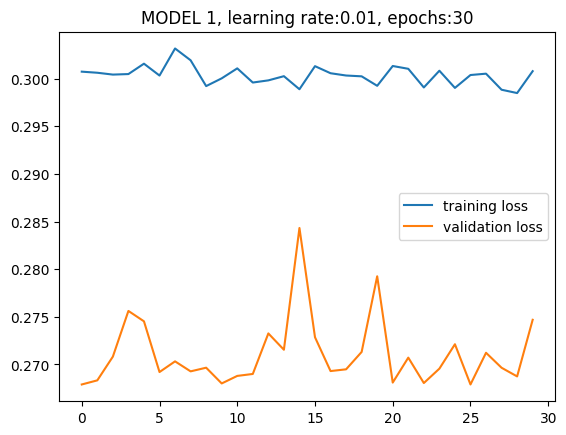

Epoch 1/10
147/147 [==============================] - 1s 4ms/step - loss: 0.2969 - Accuracy: 0.8761 - val_loss: 0.2673 - val_Accuracy: 0.8862
Epoch 2/10
147/147 [==============================] - 0s 2ms/step - loss: 0.2965 - Accuracy: 0.8765 - val_loss: 0.2683 - val_Accuracy: 0.8856
Epoch 3/10
147/147 [==============================] - 0s 2ms/step - loss: 0.2966 - Accuracy: 0.8759 - val_loss: 0.2680 - val_Accuracy: 0.8849
Epoch 4/10
147/147 [==============================] - 0s 2ms/step - loss: 0.2964 - Accuracy: 0.8769 - val_loss: 0.2676 - val_Accuracy: 0.8856
Epoch 5/10
147/147 [==============================] - 0s 2ms/step - loss: 0.2965 - Accuracy: 0.8755 - val_loss: 0.2676 - val_Accuracy: 0.8843
Epoch 6/10
147/147 [==============================] - 0s 2ms/step - loss: 0.2965 - Accuracy: 0.8752 - val_loss: 0.2679 - val_Accuracy: 0.8862
Epoch 7/10
147/147 [==============================] - 0s 2ms/step - loss: 0.2966 - Accuracy: 0.8756 - val_loss: 0.2676 - val_Accuracy: 0.8862
Epoch 

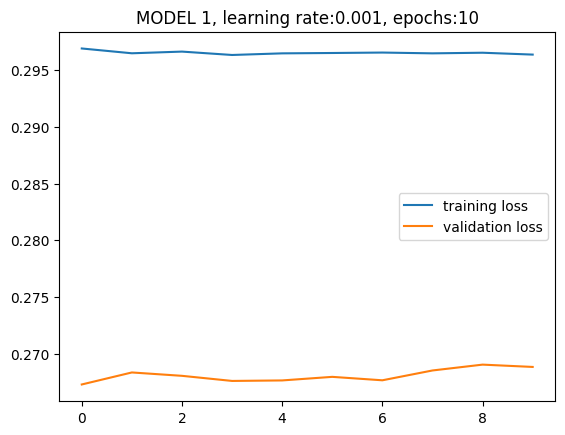

Epoch 1/20
147/147 [==============================] - 1s 5ms/step - loss: 0.2964 - Accuracy: 0.8761 - val_loss: 0.2680 - val_Accuracy: 0.8843
Epoch 2/20
147/147 [==============================] - 1s 4ms/step - loss: 0.2968 - Accuracy: 0.8767 - val_loss: 0.2678 - val_Accuracy: 0.8856
Epoch 3/20
147/147 [==============================] - 0s 3ms/step - loss: 0.2966 - Accuracy: 0.8754 - val_loss: 0.2685 - val_Accuracy: 0.8831
Epoch 4/20
147/147 [==============================] - 1s 3ms/step - loss: 0.2963 - Accuracy: 0.8766 - val_loss: 0.2674 - val_Accuracy: 0.8849
Epoch 5/20
147/147 [==============================] - 0s 3ms/step - loss: 0.2964 - Accuracy: 0.8764 - val_loss: 0.2679 - val_Accuracy: 0.8856
Epoch 6/20
147/147 [==============================] - 1s 4ms/step - loss: 0.2964 - Accuracy: 0.8765 - val_loss: 0.2677 - val_Accuracy: 0.8856
Epoch 7/20
147/147 [==============================] - 0s 3ms/step - loss: 0.2964 - Accuracy: 0.8760 - val_loss: 0.2679 - val_Accuracy: 0.8856
Epoch 

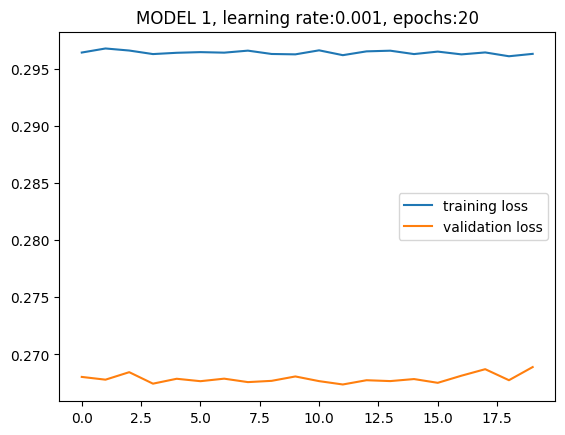

Epoch 1/30
147/147 [==============================] - 1s 4ms/step - loss: 0.2963 - Accuracy: 0.8765 - val_loss: 0.2686 - val_Accuracy: 0.8892
Epoch 2/30
147/147 [==============================] - 0s 2ms/step - loss: 0.2963 - Accuracy: 0.8757 - val_loss: 0.2679 - val_Accuracy: 0.8874
Epoch 3/30
147/147 [==============================] - 0s 2ms/step - loss: 0.2963 - Accuracy: 0.8769 - val_loss: 0.2680 - val_Accuracy: 0.8874
Epoch 4/30
147/147 [==============================] - 0s 3ms/step - loss: 0.2962 - Accuracy: 0.8762 - val_loss: 0.2676 - val_Accuracy: 0.8862
Epoch 5/30
147/147 [==============================] - 0s 2ms/step - loss: 0.2964 - Accuracy: 0.8770 - val_loss: 0.2676 - val_Accuracy: 0.8856
Epoch 6/30
147/147 [==============================] - 0s 3ms/step - loss: 0.2965 - Accuracy: 0.8751 - val_loss: 0.2677 - val_Accuracy: 0.8862
Epoch 7/30
147/147 [==============================] - 0s 3ms/step - loss: 0.2961 - Accuracy: 0.8764 - val_loss: 0.2675 - val_Accuracy: 0.8849
Epoch 

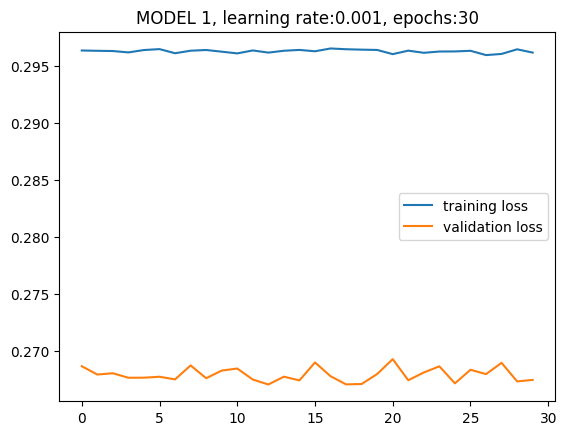

In [18]:
for lr in lr_list:
    for epoch in epoch_list:
        model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['Accuracy'])
        h = model1.fit(X_train, y_train, epochs=epoch, batch_size=batch_size, validation_split=0.1)
        plt.plot(h.history['loss'], label='training loss')
        plt.plot(h.history['val_loss'], label='validation loss')
        plt.title(f'MODEL 1, learning rate:{lr}, epochs:{epoch}')
        plt.legend()
        plt.show()

In [23]:
model2 = Sequential([
    Input(shape=(num_features,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])
model2.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 128)               4352      


                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dense_7 (Dense)             (None, 4)                 260       
                                                                 
Total params: 12868 (50.27 KB)
Trainable params: 12868 (50.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Epoch 1/10
147/147 [==============================] - 1s 4ms/step - loss: 0.9199 - Accuracy: 0.7302 - val_loss: 0.4063 - val_Accuracy: 0.8329
Epoch 2/10
147/147 [==============================] - 0s 3ms/step - loss: 0.4153 - Accuracy: 0.8251 - val_loss: 0.3884 - val_Accuracy: 0.8439
Epoch 3/10
147/147 [==============================] - 0s 3ms/step - loss: 0.3767 - Accuracy: 0.8434 - val_loss: 0.3310 - val_Accuracy: 0.8684
Epoch 4/10
147/147 [==============================] - 0s 3ms/step - loss: 0.3511 - Accuracy: 0.8550 - val_loss: 0.3755 - val_Accuracy: 0.8237
Epoch 5/10
147/147 [==============================] - 0s 3ms/step - loss: 0.3654 - Accuracy: 0.8493 - val_loss: 0.4015 - val_Accuracy: 0.8384
Epoch 6/10
147/147 [==============================] - 1s 4ms/step - loss: 0.3517 - Accuracy: 0.8501 - val_loss: 0.3013 - val_Accuracy: 0.8837
Epoch 7/10
147/147 [==============================] - 0s 3ms/step - loss: 0.3419 - Accuracy: 0.8590 - val_loss: 0.2858 - val_Accuracy: 0.8874
Epoch 

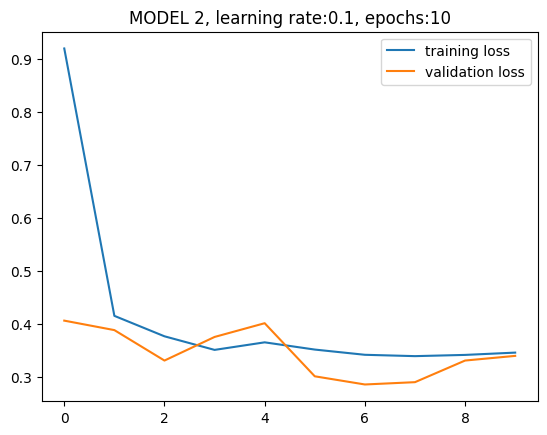

Epoch 1/20
147/147 [==============================] - 1s 3ms/step - loss: 0.3797 - Accuracy: 0.8411 - val_loss: 0.4056 - val_Accuracy: 0.8103
Epoch 2/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3517 - Accuracy: 0.8509 - val_loss: 0.2949 - val_Accuracy: 0.8813
Epoch 3/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3517 - Accuracy: 0.8541 - val_loss: 0.3394 - val_Accuracy: 0.8611
Epoch 4/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3568 - Accuracy: 0.8516 - val_loss: 0.3046 - val_Accuracy: 0.8807
Epoch 5/20
147/147 [==============================] - 0s 3ms/step - loss: 0.3583 - Accuracy: 0.8509 - val_loss: 0.3432 - val_Accuracy: 0.8488
Epoch 6/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3558 - Accuracy: 0.8546 - val_loss: 0.3539 - val_Accuracy: 0.8739
Epoch 7/20
147/147 [==============================] - 0s 3ms/step - loss: 0.3700 - Accuracy: 0.8477 - val_loss: 0.3454 - val_Accuracy: 0.8623
Epoch 

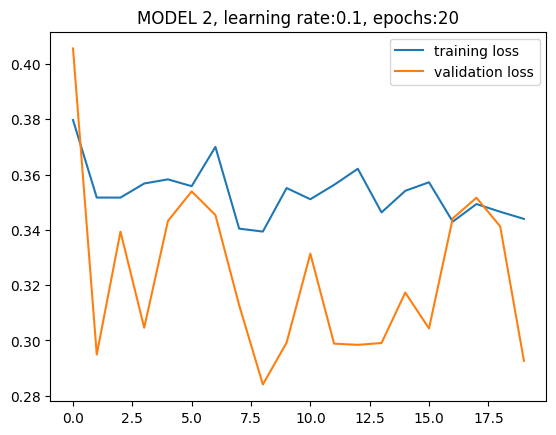

Epoch 1/30
147/147 [==============================] - 1s 3ms/step - loss: 0.3668 - Accuracy: 0.8513 - val_loss: 0.3005 - val_Accuracy: 0.8807
Epoch 2/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3649 - Accuracy: 0.8524 - val_loss: 0.3243 - val_Accuracy: 0.8623
Epoch 3/30
147/147 [==============================] - 0s 3ms/step - loss: 0.3458 - Accuracy: 0.8575 - val_loss: 0.3702 - val_Accuracy: 0.8415
Epoch 4/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3548 - Accuracy: 0.8530 - val_loss: 0.3510 - val_Accuracy: 0.8421
Epoch 5/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3424 - Accuracy: 0.8581 - val_loss: 0.3191 - val_Accuracy: 0.8635
Epoch 6/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3452 - Accuracy: 0.8568 - val_loss: 0.3382 - val_Accuracy: 0.8574
Epoch 7/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3482 - Accuracy: 0.8569 - val_loss: 0.3272 - val_Accuracy: 0.8672
Epoch 

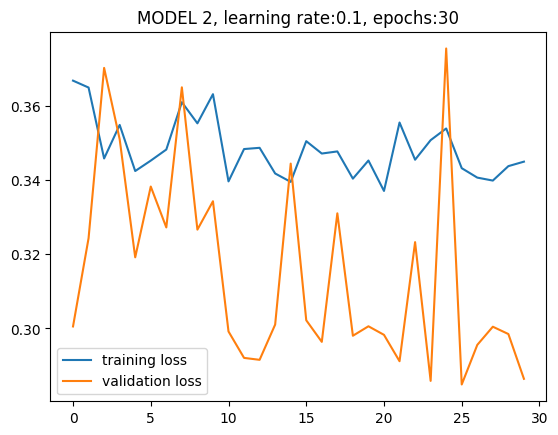

Epoch 1/10
147/147 [==============================] - 3s 7ms/step - loss: 0.3203 - Accuracy: 0.8698 - val_loss: 0.2802 - val_Accuracy: 0.8843
Epoch 2/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3194 - Accuracy: 0.8708 - val_loss: 0.2823 - val_Accuracy: 0.8886
Epoch 3/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3178 - Accuracy: 0.8703 - val_loss: 0.2815 - val_Accuracy: 0.8874
Epoch 4/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3166 - Accuracy: 0.8703 - val_loss: 0.2818 - val_Accuracy: 0.8843
Epoch 5/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3181 - Accuracy: 0.8689 - val_loss: 0.2862 - val_Accuracy: 0.8813
Epoch 6/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3176 - Accuracy: 0.8699 - val_loss: 0.2794 - val_Accuracy: 0.8849
Epoch 7/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3162 - Accuracy: 0.8704 - val_loss: 0.2788 - val_Accuracy: 0.8856
Epoch 

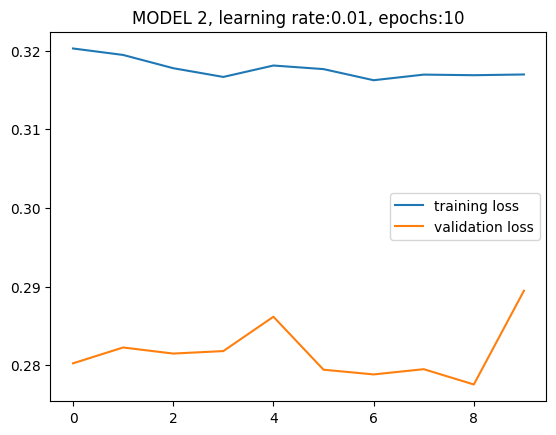

Epoch 1/20
147/147 [==============================] - 1s 3ms/step - loss: 0.3170 - Accuracy: 0.8703 - val_loss: 0.2802 - val_Accuracy: 0.8862
Epoch 2/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3151 - Accuracy: 0.8698 - val_loss: 0.2860 - val_Accuracy: 0.8788
Epoch 3/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3173 - Accuracy: 0.8692 - val_loss: 0.2791 - val_Accuracy: 0.8856
Epoch 4/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3166 - Accuracy: 0.8694 - val_loss: 0.2812 - val_Accuracy: 0.8868
Epoch 5/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3172 - Accuracy: 0.8678 - val_loss: 0.3210 - val_Accuracy: 0.8623
Epoch 6/20
147/147 [==============================] - 1s 3ms/step - loss: 0.3169 - Accuracy: 0.8696 - val_loss: 0.2786 - val_Accuracy: 0.8837
Epoch 7/20
147/147 [==============================] - 1s 4ms/step - loss: 0.3157 - Accuracy: 0.8712 - val_loss: 0.2822 - val_Accuracy: 0.8856
Epoch 

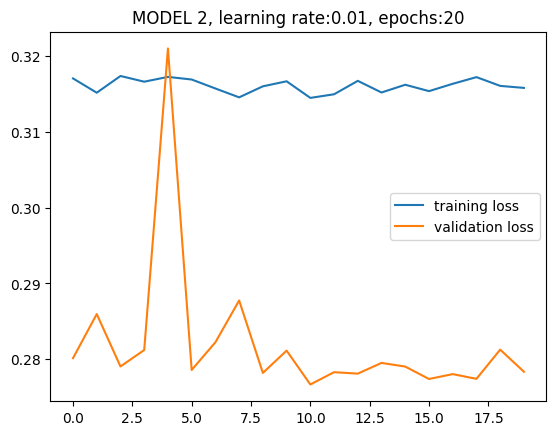

Epoch 1/30
147/147 [==============================] - 2s 6ms/step - loss: 0.3156 - Accuracy: 0.8699 - val_loss: 0.2770 - val_Accuracy: 0.8868
Epoch 2/30
147/147 [==============================] - 1s 4ms/step - loss: 0.3168 - Accuracy: 0.8706 - val_loss: 0.2776 - val_Accuracy: 0.8892
Epoch 3/30
147/147 [==============================] - 1s 4ms/step - loss: 0.3150 - Accuracy: 0.8694 - val_loss: 0.2876 - val_Accuracy: 0.8849
Epoch 4/30
147/147 [==============================] - 1s 5ms/step - loss: 0.3151 - Accuracy: 0.8690 - val_loss: 0.2764 - val_Accuracy: 0.8917
Epoch 5/30
147/147 [==============================] - 1s 4ms/step - loss: 0.3142 - Accuracy: 0.8711 - val_loss: 0.2773 - val_Accuracy: 0.8898
Epoch 6/30
147/147 [==============================] - 1s 4ms/step - loss: 0.3145 - Accuracy: 0.8710 - val_loss: 0.2780 - val_Accuracy: 0.8892
Epoch 7/30
147/147 [==============================] - 1s 4ms/step - loss: 0.3147 - Accuracy: 0.8692 - val_loss: 0.2767 - val_Accuracy: 0.8905
Epoch 

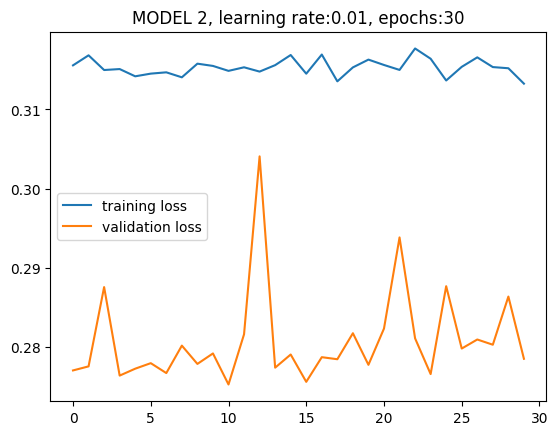

Epoch 1/10
147/147 [==============================] - 2s 6ms/step - loss: 0.3109 - Accuracy: 0.8715 - val_loss: 0.2764 - val_Accuracy: 0.8886
Epoch 2/10
147/147 [==============================] - 1s 4ms/step - loss: 0.3115 - Accuracy: 0.8701 - val_loss: 0.2759 - val_Accuracy: 0.8898
Epoch 3/10
147/147 [==============================] - 1s 4ms/step - loss: 0.3107 - Accuracy: 0.8715 - val_loss: 0.2759 - val_Accuracy: 0.8898
Epoch 4/10
147/147 [==============================] - 1s 4ms/step - loss: 0.3108 - Accuracy: 0.8707 - val_loss: 0.2762 - val_Accuracy: 0.8892
Epoch 5/10
147/147 [==============================] - 1s 4ms/step - loss: 0.3106 - Accuracy: 0.8711 - val_loss: 0.2760 - val_Accuracy: 0.8880
Epoch 6/10
147/147 [==============================] - 1s 5ms/step - loss: 0.3109 - Accuracy: 0.8722 - val_loss: 0.2760 - val_Accuracy: 0.8898
Epoch 7/10
147/147 [==============================] - 1s 4ms/step - loss: 0.3106 - Accuracy: 0.8712 - val_loss: 0.2776 - val_Accuracy: 0.8868
Epoch 

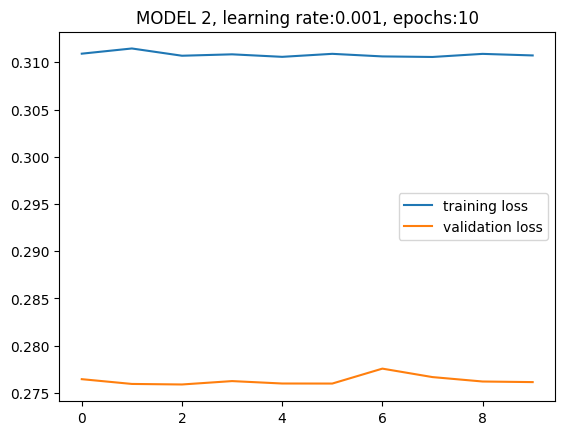

Epoch 1/20
147/147 [==============================] - 3s 7ms/step - loss: 0.3105 - Accuracy: 0.8724 - val_loss: 0.2763 - val_Accuracy: 0.8905
Epoch 2/20
147/147 [==============================] - 1s 4ms/step - loss: 0.3107 - Accuracy: 0.8715 - val_loss: 0.2780 - val_Accuracy: 0.8892
Epoch 3/20
147/147 [==============================] - 1s 4ms/step - loss: 0.3109 - Accuracy: 0.8720 - val_loss: 0.2768 - val_Accuracy: 0.8905
Epoch 4/20
147/147 [==============================] - 1s 4ms/step - loss: 0.3105 - Accuracy: 0.8718 - val_loss: 0.2764 - val_Accuracy: 0.8905
Epoch 5/20
147/147 [==============================] - 1s 4ms/step - loss: 0.3107 - Accuracy: 0.8713 - val_loss: 0.2761 - val_Accuracy: 0.8911
Epoch 6/20
147/147 [==============================] - 1s 4ms/step - loss: 0.3108 - Accuracy: 0.8720 - val_loss: 0.2763 - val_Accuracy: 0.8911
Epoch 7/20
147/147 [==============================] - 1s 4ms/step - loss: 0.3107 - Accuracy: 0.8717 - val_loss: 0.2761 - val_Accuracy: 0.8880
Epoch 

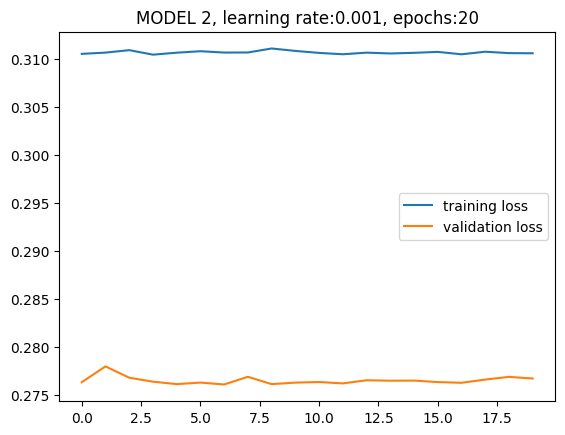

Epoch 1/30
147/147 [==============================] - 2s 6ms/step - loss: 0.3106 - Accuracy: 0.8721 - val_loss: 0.2760 - val_Accuracy: 0.8905
Epoch 2/30
147/147 [==============================] - 1s 4ms/step - loss: 0.3107 - Accuracy: 0.8717 - val_loss: 0.2760 - val_Accuracy: 0.8898
Epoch 3/30
147/147 [==============================] - 1s 4ms/step - loss: 0.3105 - Accuracy: 0.8714 - val_loss: 0.2772 - val_Accuracy: 0.8892
Epoch 4/30
147/147 [==============================] - 1s 4ms/step - loss: 0.3104 - Accuracy: 0.8723 - val_loss: 0.2762 - val_Accuracy: 0.8898
Epoch 5/30
147/147 [==============================] - 1s 4ms/step - loss: 0.3108 - Accuracy: 0.8721 - val_loss: 0.2760 - val_Accuracy: 0.8917
Epoch 6/30
147/147 [==============================] - 1s 5ms/step - loss: 0.3105 - Accuracy: 0.8715 - val_loss: 0.2763 - val_Accuracy: 0.8905
Epoch 7/30
147/147 [==============================] - 1s 6ms/step - loss: 0.3106 - Accuracy: 0.8725 - val_loss: 0.2761 - val_Accuracy: 0.8892
Epoch 

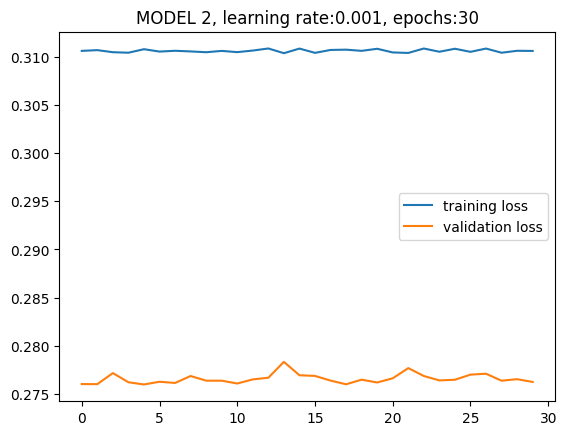

In [24]:
for lr in lr_list:
    for epoch in epoch_list:
        model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['Accuracy'])
        h = model2.fit(X_train, y_train, epochs=epoch, batch_size=batch_size, validation_split=0.1)
        plt.plot(h.history['loss'], label='training loss')
        plt.plot(h.history['val_loss'], label='validation loss')
        plt.title(f'MODEL 2, learning rate:{lr}, epochs:{epoch}')
        plt.legend()
        plt.show()

In [25]:
model3 = Sequential([
    Input(shape=(num_features,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])
model3.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 128)               4352      
                                                                 
 dense_9 (Dense)             (None, 64)                8256      


                                                                 
 dense_10 (Dense)            (None, 32)                2080      
                                                                 
 dense_11 (Dense)            (None, 4)                 132       
                                                                 
Total params: 14820 (57.89 KB)
Trainable params: 14820 (57.89 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Epoch 1/10
147/147 [==============================] - 1s 3ms/step - loss: 1.1273 - Accuracy: 0.4598 - val_loss: 0.7089 - val_Accuracy: 0.6144
Epoch 2/10
147/147 [==============================] - 0s 2ms/step - loss: 0.5189 - Accuracy: 0.7623 - val_loss: 0.3819 - val_Accuracy: 0.8372
Epoch 3/10
147/147 [==============================] - 0s 2ms/step - loss: 0.4083 - Accuracy: 0.8213 - val_loss: 0.3582 - val_Accuracy: 0.8543
Epoch 4/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3844 - Accuracy: 0.8385 - val_loss: 0.3364 - val_Accuracy: 0.8507
Epoch 5/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3684 - Accuracy: 0.8466 - val_loss: 0.4074 - val_Accuracy: 0.8341
Epoch 6/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3686 - Accuracy: 0.8455 - val_loss: 0.3227 - val_Accuracy: 0.8660
Epoch 7/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3676 - Accuracy: 0.8498 - val_loss: 0.3119 - val_Accuracy: 0.8739
Epoch 

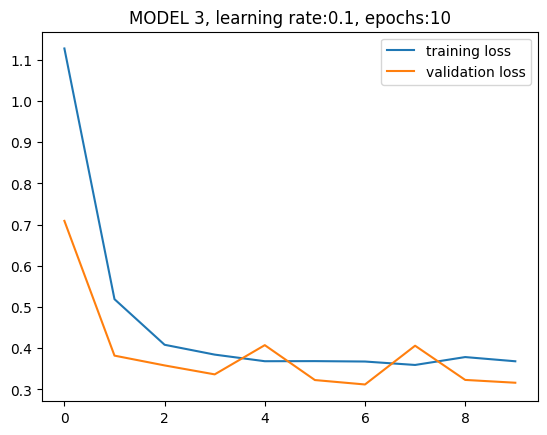

Epoch 1/20
147/147 [==============================] - 1s 3ms/step - loss: 0.3796 - Accuracy: 0.8439 - val_loss: 0.3141 - val_Accuracy: 0.8739
Epoch 2/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3518 - Accuracy: 0.8583 - val_loss: 0.3366 - val_Accuracy: 0.8537
Epoch 3/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3520 - Accuracy: 0.8558 - val_loss: 0.3459 - val_Accuracy: 0.8611
Epoch 4/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3722 - Accuracy: 0.8483 - val_loss: 0.3232 - val_Accuracy: 0.8794
Epoch 5/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3649 - Accuracy: 0.8503 - val_loss: 0.3238 - val_Accuracy: 0.8647
Epoch 6/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3547 - Accuracy: 0.8568 - val_loss: 0.3475 - val_Accuracy: 0.8537
Epoch 7/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3603 - Accuracy: 0.8515 - val_loss: 0.3167 - val_Accuracy: 0.8647
Epoch 

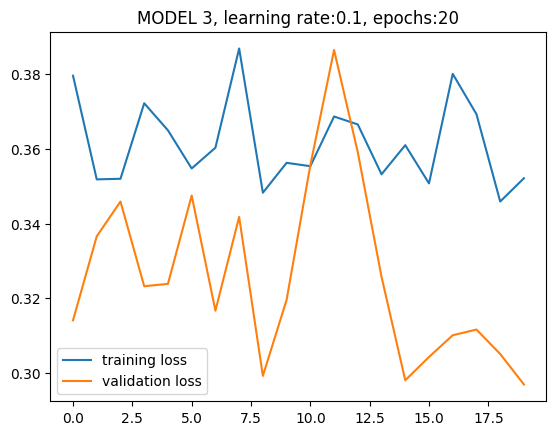

Epoch 1/30
147/147 [==============================] - 1s 3ms/step - loss: 0.3619 - Accuracy: 0.8515 - val_loss: 0.3456 - val_Accuracy: 0.8550
Epoch 2/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3557 - Accuracy: 0.8568 - val_loss: 0.3480 - val_Accuracy: 0.8599
Epoch 3/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3641 - Accuracy: 0.8488 - val_loss: 0.3476 - val_Accuracy: 0.8562
Epoch 4/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3517 - Accuracy: 0.8558 - val_loss: 0.3118 - val_Accuracy: 0.8647
Epoch 5/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3530 - Accuracy: 0.8582 - val_loss: 0.3012 - val_Accuracy: 0.8794
Epoch 6/30
147/147 [==============================] - 0s 3ms/step - loss: 0.3505 - Accuracy: 0.8583 - val_loss: 0.3287 - val_Accuracy: 0.8574
Epoch 7/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3529 - Accuracy: 0.8535 - val_loss: 0.3298 - val_Accuracy: 0.8739
Epoch 

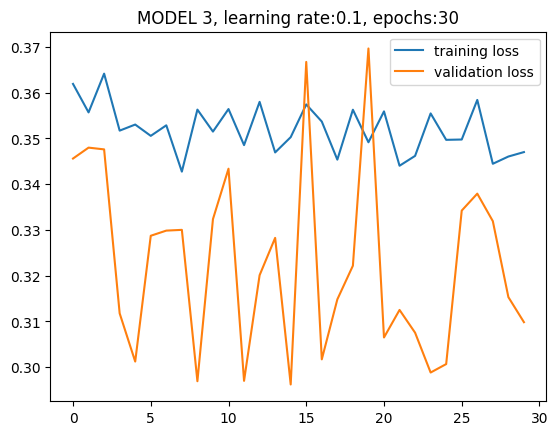

Epoch 1/10
147/147 [==============================] - 1s 3ms/step - loss: 0.3283 - Accuracy: 0.8673 - val_loss: 0.2904 - val_Accuracy: 0.8837
Epoch 2/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3254 - Accuracy: 0.8666 - val_loss: 0.3052 - val_Accuracy: 0.8764
Epoch 3/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3261 - Accuracy: 0.8675 - val_loss: 0.2919 - val_Accuracy: 0.8819
Epoch 4/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3259 - Accuracy: 0.8684 - val_loss: 0.2898 - val_Accuracy: 0.8831
Epoch 5/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3263 - Accuracy: 0.8654 - val_loss: 0.2991 - val_Accuracy: 0.8831
Epoch 6/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3236 - Accuracy: 0.8667 - val_loss: 0.3088 - val_Accuracy: 0.8690
Epoch 7/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3253 - Accuracy: 0.8671 - val_loss: 0.3000 - val_Accuracy: 0.8825
Epoch 

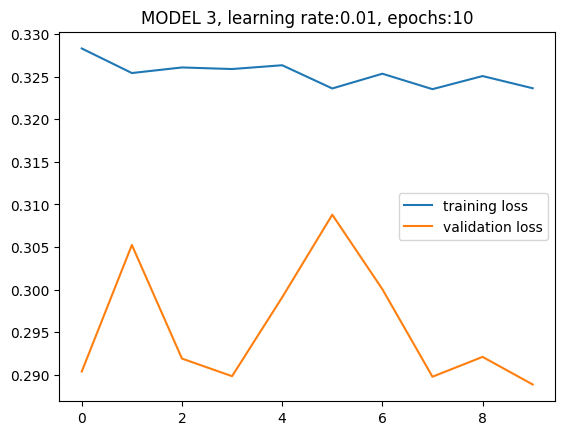

Epoch 1/20
147/147 [==============================] - 1s 3ms/step - loss: 0.3256 - Accuracy: 0.8664 - val_loss: 0.2894 - val_Accuracy: 0.8831
Epoch 2/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3246 - Accuracy: 0.8684 - val_loss: 0.2897 - val_Accuracy: 0.8831
Epoch 3/20
147/147 [==============================] - 0s 3ms/step - loss: 0.3231 - Accuracy: 0.8669 - val_loss: 0.2928 - val_Accuracy: 0.8831
Epoch 4/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3255 - Accuracy: 0.8678 - val_loss: 0.2897 - val_Accuracy: 0.8843
Epoch 5/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3240 - Accuracy: 0.8666 - val_loss: 0.2922 - val_Accuracy: 0.8843
Epoch 6/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3243 - Accuracy: 0.8673 - val_loss: 0.2868 - val_Accuracy: 0.8843
Epoch 7/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3242 - Accuracy: 0.8670 - val_loss: 0.2872 - val_Accuracy: 0.8856
Epoch 

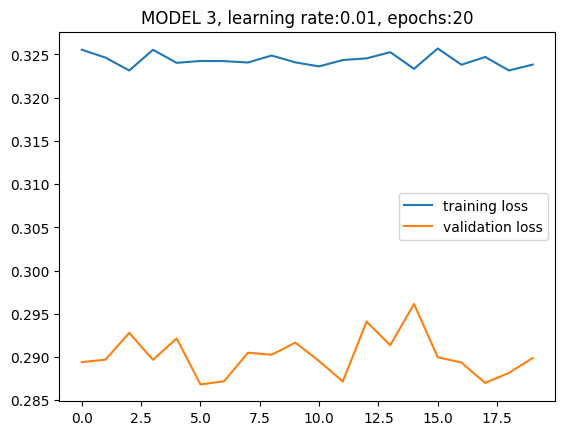

Epoch 1/30
147/147 [==============================] - 1s 3ms/step - loss: 0.3253 - Accuracy: 0.8672 - val_loss: 0.2913 - val_Accuracy: 0.8837
Epoch 2/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3236 - Accuracy: 0.8683 - val_loss: 0.2880 - val_Accuracy: 0.8800
Epoch 3/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3242 - Accuracy: 0.8677 - val_loss: 0.2874 - val_Accuracy: 0.8819
Epoch 4/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3236 - Accuracy: 0.8669 - val_loss: 0.2893 - val_Accuracy: 0.8856
Epoch 5/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3236 - Accuracy: 0.8674 - val_loss: 0.2879 - val_Accuracy: 0.8843
Epoch 6/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3235 - Accuracy: 0.8674 - val_loss: 0.2868 - val_Accuracy: 0.8849
Epoch 7/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3232 - Accuracy: 0.8669 - val_loss: 0.2876 - val_Accuracy: 0.8837
Epoch 

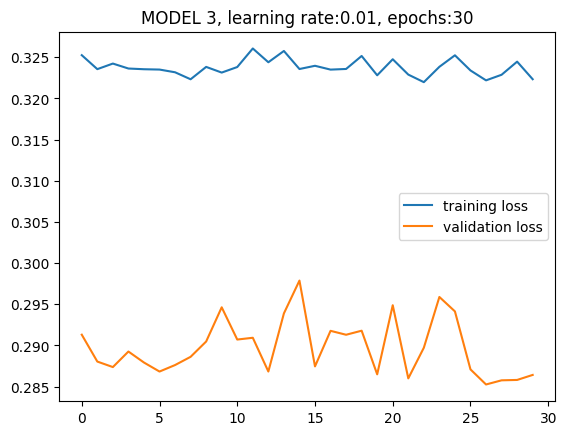

Epoch 1/10
147/147 [==============================] - 1s 3ms/step - loss: 0.3199 - Accuracy: 0.8679 - val_loss: 0.2862 - val_Accuracy: 0.8800
Epoch 2/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3197 - Accuracy: 0.8686 - val_loss: 0.2854 - val_Accuracy: 0.8819
Epoch 3/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3197 - Accuracy: 0.8684 - val_loss: 0.2855 - val_Accuracy: 0.8843
Epoch 4/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3196 - Accuracy: 0.8683 - val_loss: 0.2868 - val_Accuracy: 0.8849
Epoch 5/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3195 - Accuracy: 0.8694 - val_loss: 0.2879 - val_Accuracy: 0.8837
Epoch 6/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3197 - Accuracy: 0.8686 - val_loss: 0.2861 - val_Accuracy: 0.8843
Epoch 7/10
147/147 [==============================] - 0s 2ms/step - loss: 0.3197 - Accuracy: 0.8687 - val_loss: 0.2869 - val_Accuracy: 0.8825
Epoch 

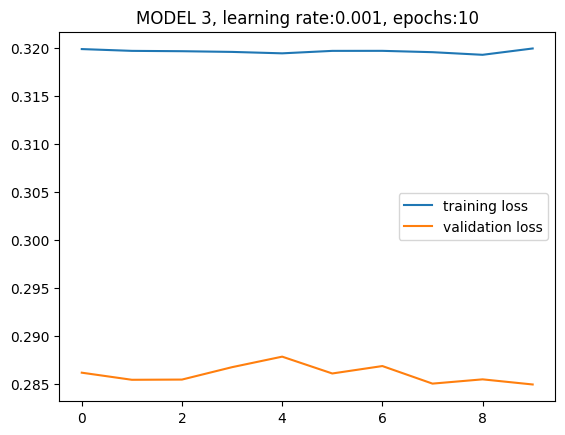

Epoch 1/20
147/147 [==============================] - 1s 3ms/step - loss: 0.3197 - Accuracy: 0.8687 - val_loss: 0.2861 - val_Accuracy: 0.8800
Epoch 2/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3196 - Accuracy: 0.8688 - val_loss: 0.2854 - val_Accuracy: 0.8843
Epoch 3/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3196 - Accuracy: 0.8682 - val_loss: 0.2856 - val_Accuracy: 0.8837
Epoch 4/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3197 - Accuracy: 0.8683 - val_loss: 0.2851 - val_Accuracy: 0.8825
Epoch 5/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3195 - Accuracy: 0.8690 - val_loss: 0.2855 - val_Accuracy: 0.8831
Epoch 6/20
147/147 [==============================] - 0s 3ms/step - loss: 0.3197 - Accuracy: 0.8686 - val_loss: 0.2857 - val_Accuracy: 0.8825
Epoch 7/20
147/147 [==============================] - 0s 2ms/step - loss: 0.3196 - Accuracy: 0.8683 - val_loss: 0.2852 - val_Accuracy: 0.8843
Epoch 

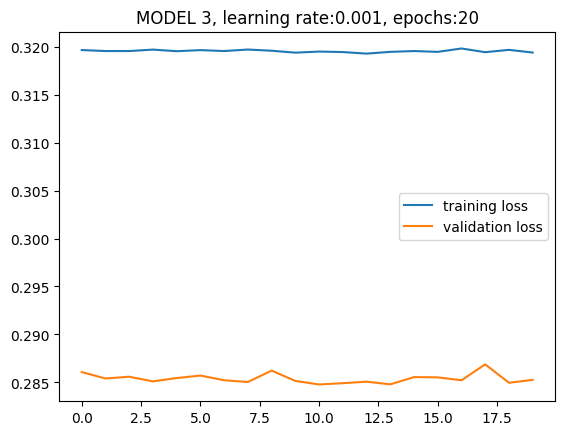

Epoch 1/30
147/147 [==============================] - 1s 3ms/step - loss: 0.3196 - Accuracy: 0.8686 - val_loss: 0.2859 - val_Accuracy: 0.8831
Epoch 2/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3195 - Accuracy: 0.8680 - val_loss: 0.2851 - val_Accuracy: 0.8825
Epoch 3/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3195 - Accuracy: 0.8695 - val_loss: 0.2848 - val_Accuracy: 0.8856
Epoch 4/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3194 - Accuracy: 0.8681 - val_loss: 0.2856 - val_Accuracy: 0.8819
Epoch 5/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3195 - Accuracy: 0.8692 - val_loss: 0.2855 - val_Accuracy: 0.8831
Epoch 6/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3193 - Accuracy: 0.8681 - val_loss: 0.2868 - val_Accuracy: 0.8856
Epoch 7/30
147/147 [==============================] - 0s 2ms/step - loss: 0.3197 - Accuracy: 0.8690 - val_loss: 0.2848 - val_Accuracy: 0.8831
Epoch 

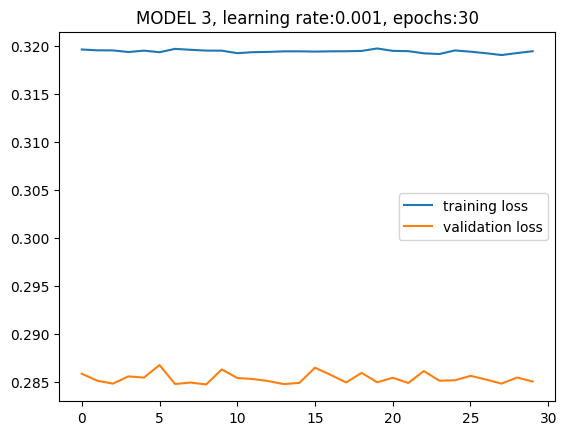

In [26]:
for lr in lr_list:
    for epoch in epoch_list:
        model3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['Accuracy'])
        h = model3.fit(X_train, y_train, epochs=epoch, batch_size=batch_size, validation_split=0.1)
        plt.plot(h.history['loss'], label='training loss')
        plt.plot(h.history['val_loss'], label='validation loss')
        plt.title(f'MODEL 3, learning rate:{lr}, epochs:{epoch}')
        plt.legend()
        plt.show()